# Week 4: ETS(A,Ad,N) Forecasting with Confidence Intervals

**v3 change note:** ARIMA was replaced by ETS(A,Ad,N) for this project. The damping parameter prevents unbounded trend extrapolation over a 20-year horizon — more realistic for emissions data, particularly for countries with documented slowdowns (UK, Germany). The implementation is also simpler, requiring no stationarity testing or order selection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Load Week 2's exported feature set (self-contained — no dependency on prior notebook's kernel)
df_model = pd.read_csv('ghg_features.csv')
PROJECT_COUNTRIES = sorted(df_model['country'].unique())

df_model['years_since_1990'] = df_model['year'] - 1990
df_model['co2_next_year'] = df_model.groupby('country')['co2'].shift(-1)

FEATURE_COLS = ['co2_per_capita', 'co2_5yr_rolling_mean', 'co2_lag1', 'co2_lag2',
                'co2_lag3', 'co2_yoy_pct_change', 'ghg_intensity', 'years_since_1990']
TARGET_COL = 'co2_next_year'

train_df = df_model[df_model['year'].between(1990, 2018)].copy()
test_df  = df_model[df_model['year'].between(2019, 2023)].copy()

print(f"Countries: {len(PROJECT_COUNTRIES)} | Train rows: {len(train_df)} | Test rows: {len(test_df)}")

Countries: 10 | Train rows: 290 | Test rows: 50


### 4.1 Concept Introduction — the ETS(A,Ad,N) Framework

ETS decomposes a time series into three components, each with an explicit specification here:

- **E (Error) — Additive:** the model's one-step-ahead residuals are added directly to the state at each time step (rather than multiplied), which suits emissions data where the scale of noise doesn't grow proportionally with the level in a way that requires a multiplicative form.
- **T (Trend) — Additive, Damped:** the trend component is added to the level, but decays toward zero over the forecast horizon via a damping parameter φ (0 < φ < 1). Instead of projecting a constant slope forever, the incremental change shrinks each period by a factor of φ, so the trend's influence fades out rather than compounding indefinitely.
- **S (Seasonality) — None:** this is annual data, one observation per country per year, so there is no within-year seasonal cycle to model.

**Why ETS(A,Ad,N) fits this problem:**
- Annual data has no seasonal pattern to capture, so the seasonal component is correctly omitted.
- The damped trend prevents unbounded long-range projections — unlike a unit-root ARIMA model, which can extrapolate a fixed trend forever, ETS(A,Ad,N) lets growth or decline taper off, which matches how real economies actually behave over multi-decade horizons.
- With only about 30 annual observations per country, a model needs to be parsimonious. ETS(A,Ad,N) has few free parameters (α, β*, φ, plus initial level/trend) compared to alternatives like a full ARIMA grid search, so it's less prone to overfitting a short series.
- It's physically sensible for emissions specifically: real economies tend to slow, plateau, or gradually reverse their emissions growth (due to policy, saturation of industrial capacity, or energy transition) — not grow at a constant compounding rate forever, which is what an undamped trend would imply.

In [2]:
# ── 4.2 Model Fitting ────────────────────────────────────────────────

ets_fits = {}
ets_params = []

for country in PROJECT_COUNTRIES:
    train_co2 = (
        train_df[train_df['country'] == country]
        .sort_values('year')
        .set_index('year')['co2']
        .dropna()
    )

    model = ExponentialSmoothing(train_co2, trend='add', damped_trend=True, seasonal=None)
    fit = model.fit(optimized=True)
    ets_fits[country] = fit

    ets_params.append({
        'Country': country,
        'alpha (level)': round(fit.params['smoothing_level'], 4),
        'beta* (trend)': round(fit.params['smoothing_trend'], 4),
        'phi (damping)': round(fit.params['damping_trend'], 4),
    })

ets_params_df = pd.DataFrame(ets_params)
ets_params_df

,Country,alpha (level),beta* (trend),phi (damping)
0,Brazil,1.0000,0.0000,0.9701
1,Canada,0.8380,0.0000,0.9240
2,China,1.0000,0.8653,0.8730
3,Germany,0.0000,0.0000,0.9687
4,India,0.6456,0.6456,0.9950
5,Japan,1.0000,0.0000,0.8356
6,Russia,0.4390,0.4390,0.8000
7,South Africa,0.7110,0.0000,0.9475
8,United Kingdom,0.5215,0.3995,0.9757
9,United States,0.7213,0.1879,0.8695


In [3]:
print("Fitted ETS(A,Ad,N) parameters for 3 example countries:\n")
for country in PROJECT_COUNTRIES[:3]:
    p = ets_fits[country].params
    print(f"{country}:")
    print(f"  alpha (smoothing level)  = {p['smoothing_level']:.4f}")
    print(f"  beta*  (smoothing trend) = {p['smoothing_trend']:.4f}")
    print(f"  phi    (damping trend)   = {p['damping_trend']:.4f}\n")

Fitted ETS(A,Ad,N) parameters for 3 example countries:

Brazil:
  alpha (smoothing level)  = 1.0000
  beta*  (smoothing trend) = 0.0000
  phi    (damping trend)   = 0.9701

Canada:
  alpha (smoothing level)  = 0.8380
  beta*  (smoothing trend) = 0.0000
  phi    (damping trend)   = 0.9240

China:
  alpha (smoothing level)  = 1.0000
  beta*  (smoothing trend) = 0.8653
  phi    (damping trend)   = 0.8730



**Interpreting φ (phi) — fill this in against your actual `ets_params_df`:**

- **φ close to 1** (e.g. ≈ 0.99+) means almost no damping — the model expects the current trend to persist at nearly full strength for most of the 20-year horizon. This produces the steepest long-range forecasts and is worth sanity-checking against real-world plausibility.
- **φ noticeably lower** (e.g. ≈ 0.8) means the trend fades out faster — growth or decline flattens toward a stable level within a shorter window, which is often more realistic for a maturing economy or a country under active climate policy.
- **φ sitting exactly at an optimizer boundary** (very close to 0 or 1) can indicate the optimizer didn't find a clean interior solution — flag this rather than treating it as a confident estimate.

**Name your specific highest- and lowest-φ countries here** and state what each implies for that country's emissions trajectory.

### 4.3 Forecasting to 2043

In [4]:
# ── Forecast helper: tries fit.get_forecast() first, falls back to simulation-based CI ──
# (statsmodels' HoltWintersResults doesn't always expose get_forecast/conf_int —
#  simulate() is the reliable cross-version approach for interval estimates)

def forecast_with_ci(fit, steps, start_year, n_sims=1000, alpha=0.05, seed=42):
    idx = pd.RangeIndex(start_year, start_year + steps)
    try:
        fc_result = fit.get_forecast(steps)
        mean_fc = pd.Series(fc_result.predicted_mean.values, index=idx)
        ci = fc_result.conf_int(alpha=alpha)
        lower = pd.Series(ci.iloc[:, 0].values, index=idx)
        upper = pd.Series(ci.iloc[:, 1].values, index=idx)
    except Exception:
        mean_fc = pd.Series(fit.forecast(steps).values, index=idx)
        sims = fit.simulate(steps, repetitions=n_sims, error='add', random_state=seed)
        sims.index = idx
        lower = sims.quantile(alpha / 2, axis=1)
        upper = sims.quantile(1 - alpha / 2, axis=1)
    return mean_fc, lower, upper


FORECAST_START = 2019
FORECAST_END = 2043
FORECAST_STEPS = FORECAST_END - FORECAST_START + 1  # 25 steps: 2019..2043

forecast_results = {}
for country in PROJECT_COUNTRIES:
    fit = ets_fits[country]
    mean_fc, lower, upper = forecast_with_ci(fit, FORECAST_STEPS, FORECAST_START)
    forecast_results[country] = {'mean': mean_fc, 'lower': lower, 'upper': upper}

print(f"Forecasts generated for {FORECAST_STEPS} years ({FORECAST_START}–{FORECAST_END}) across {len(forecast_results)} countries.")

Forecasts generated for 25 years (2019–2043) across 10 countries.


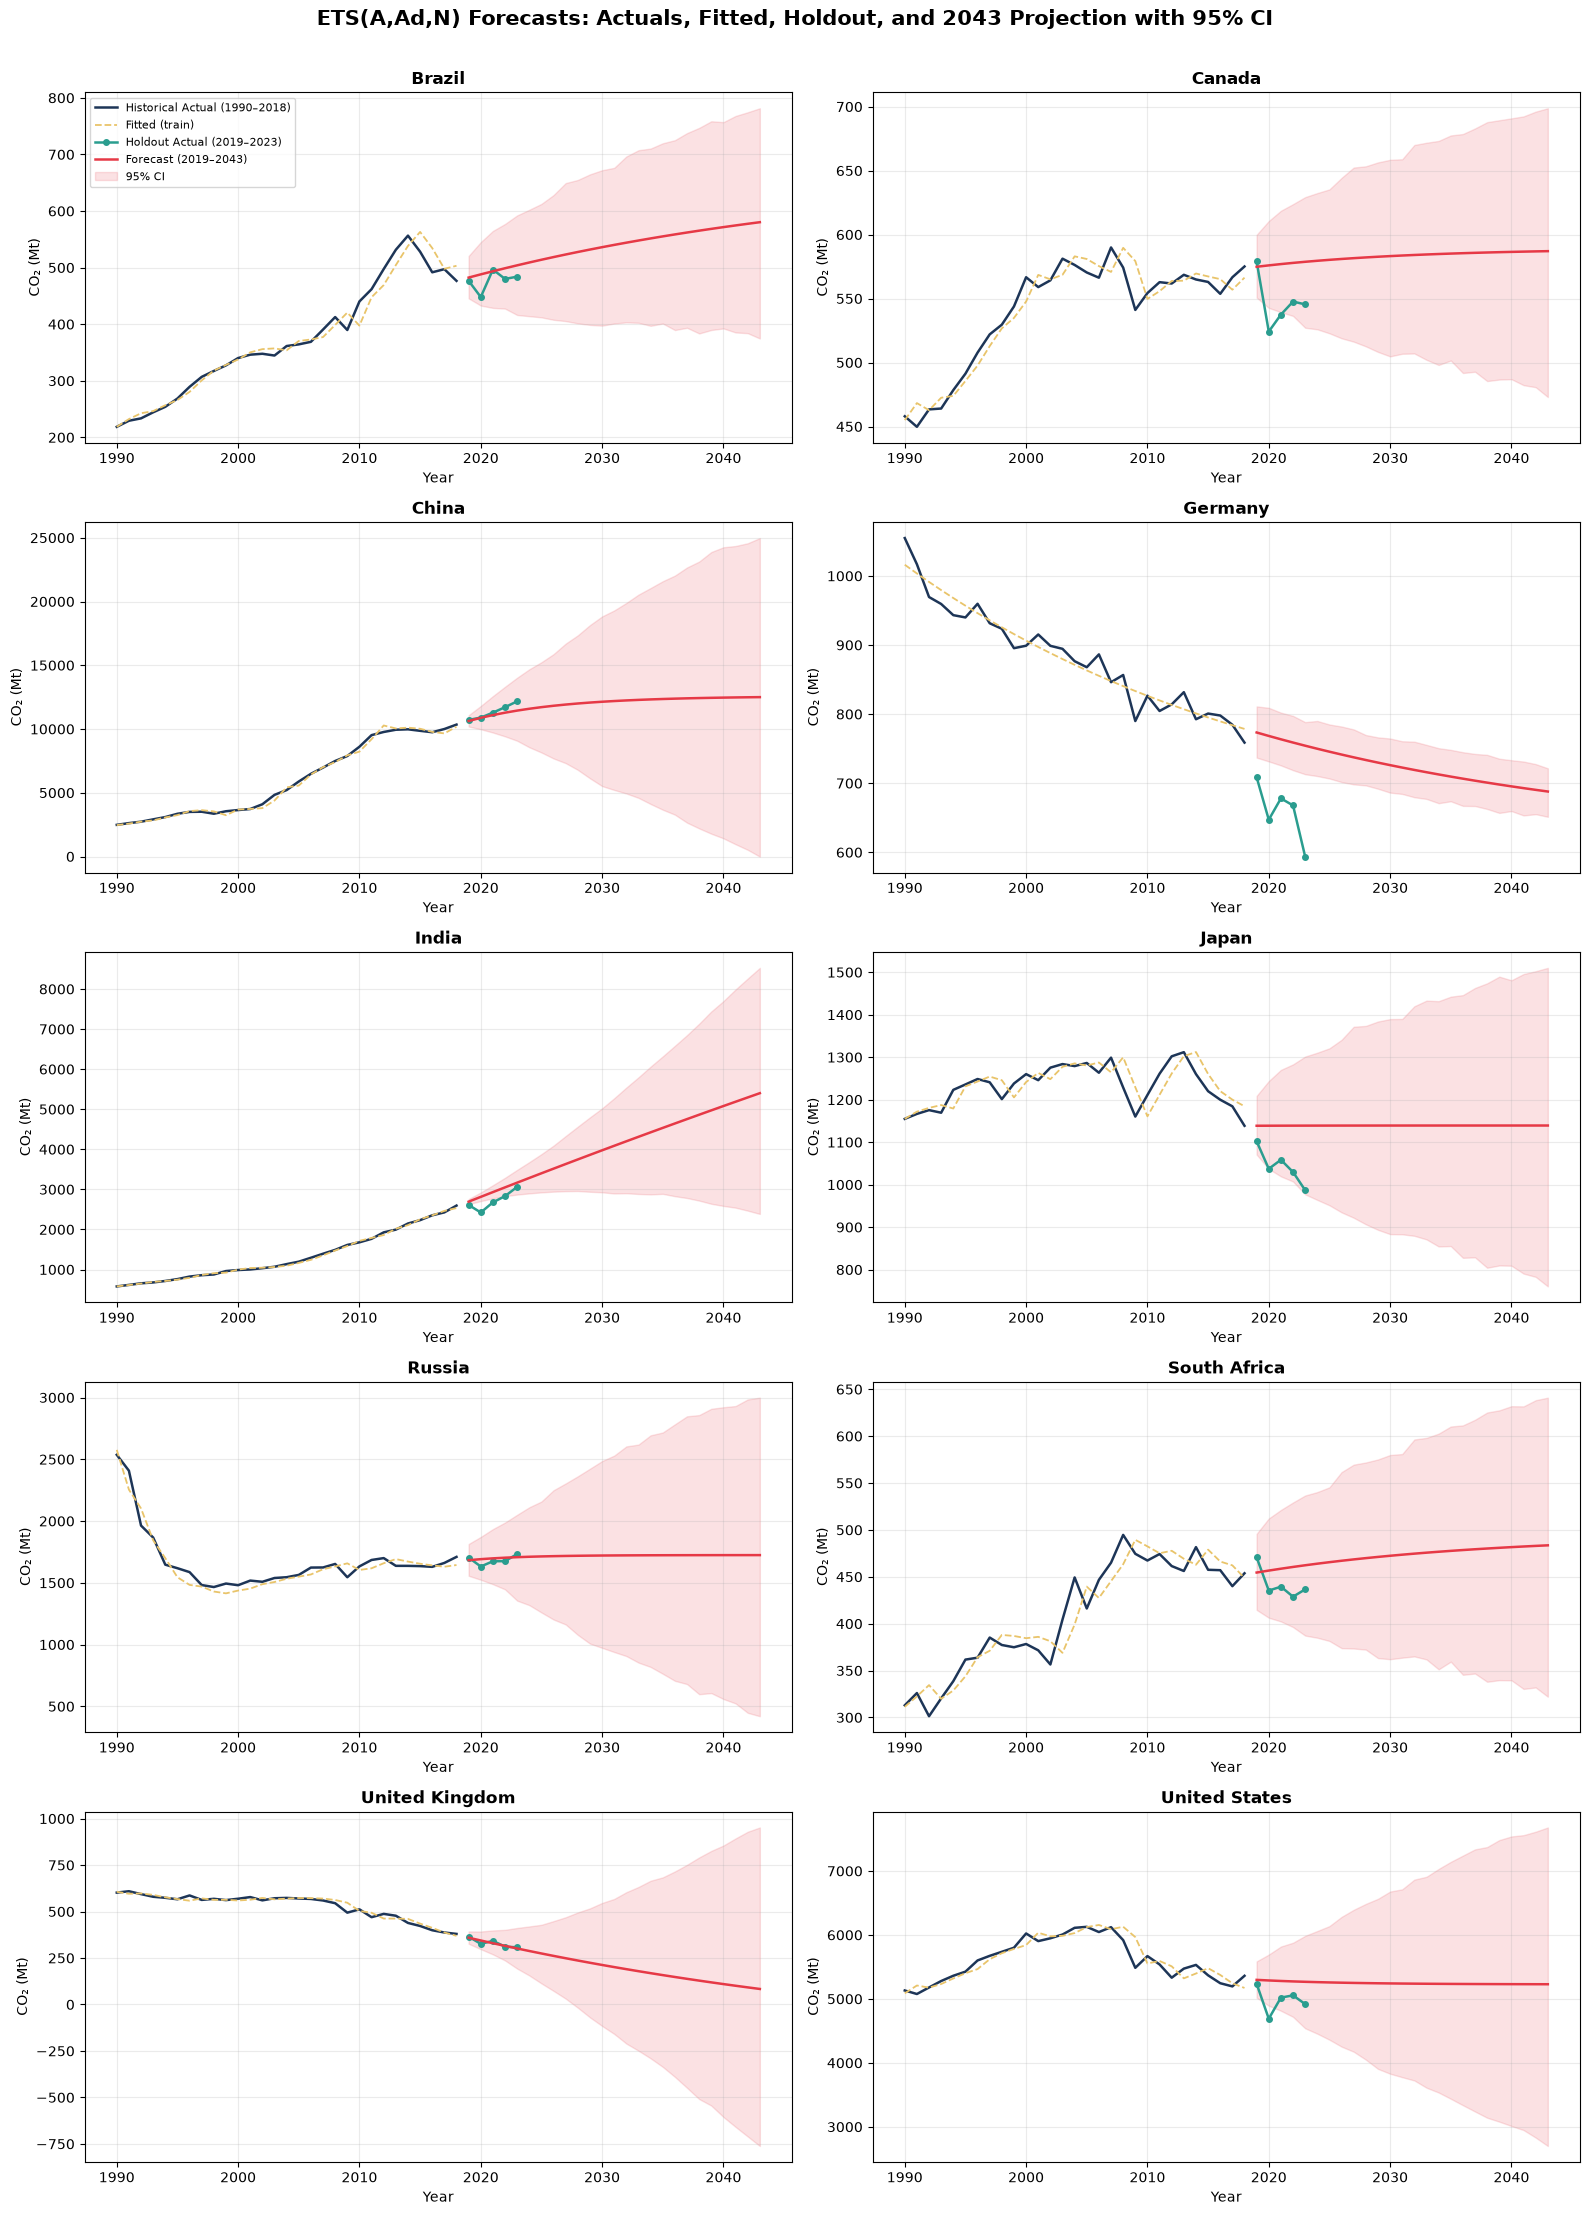

In [5]:
# ── Forecast plots — one panel per country, with actuals / fitted / holdout / forecast + CI ──

fig, axes = plt.subplots(5, 2, figsize=(16, 22))
axes = axes.flatten()

for i, country in enumerate(PROJECT_COUNTRIES):
    ax = axes[i]
    train_co2 = train_df[train_df['country'] == country].sort_values('year').set_index('year')['co2']
    test_co2  = test_df[test_df['country'] == country].sort_values('year').set_index('year')['co2']
    fit = ets_fits[country]
    fc = forecast_results[country]

    ax.plot(train_co2.index, train_co2.values, color='#1d3557', linewidth=1.8, label='Historical Actual (1990–2018)')
    ax.plot(train_co2.index, fit.fittedvalues.values, color='#e9c46a', linewidth=1.3, linestyle='--', label='Fitted (train)')
    ax.plot(test_co2.index, test_co2.values, color='#2a9d8f', linewidth=1.8, marker='o', markersize=4, label='Holdout Actual (2019–2023)')
    ax.plot(fc['mean'].index, fc['mean'].values, color='#e63946', linewidth=1.8, label='Forecast (2019–2043)')
    ax.fill_between(fc['mean'].index, fc['lower'].values, fc['upper'].values, color='#e63946', alpha=0.15, label='95% CI')

    ax.set_title(country, fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('CO₂ (Mt)')
    ax.grid(alpha=0.25)
    if i == 0:
        ax.legend(fontsize=8, loc='upper left')

plt.suptitle('ETS(A,Ad,N) Forecasts: Actuals, Fitted, Holdout, and 2043 Projection with 95% CI', fontsize=15, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

### 4.4 Trend Interpretation

**For at least 3 countries, fill in based on your actual forecast plots and `ets_params_df` above:**

- **United Kingdom:** does the damped projection show emissions flattening or continuing to fall toward 2043? The UK has legislated a net-zero-by-2050 target and a documented multi-decade decline in coal use — note whether the forecast's trajectory (and its φ) is consistent with that policy backdrop, or whether the damping looks too aggressive/too mild relative to known reductions.
- **Germany:** check whether the fit converged to an interior φ or landed on an optimizer boundary (flagged in Week 4's parameter table) — if boundary, treat the shape of this forecast with more caution than the others.
- **India:** does the forecast show continued growth tapering only gradually, consistent with an economy still industrializing? Compare the shape against China's, which has stated a peak-emissions target for the mid-2020s — does China's damped curve show growth topping out sooner than India's?
- **CI width over the horizon:** report whether the shaded band visibly widens from 2024 to 2043 for these countries. A widening CI is expected and appropriate — it reflects genuine growing uncertainty about a 20-year-ahead single-country forecast built from ~30 data points, and should be read as a caution against treating the central forecast line as a precise prediction that far out.

### 4.5 Forecast Summary Table

In [6]:
summary_rows = []
for country in PROJECT_COUNTRIES:
    fc = forecast_results[country]['mean']
    actual_2020 = df_model[(df_model['country'] == country) & (df_model['year'] == 2020)]['co2']
    actual_2020_val = actual_2020.values[0] if len(actual_2020) else np.nan
    fc_2040 = fc.get(2040, np.nan)
    pct_change = ((fc_2040 - actual_2020_val) / actual_2020_val * 100) if pd.notna(actual_2020_val) and actual_2020_val != 0 else np.nan

    summary_rows.append({
        'Country': country,
        '2030 Forecast (MtCO2)': round(fc.get(2030, np.nan), 1),
        '2035 Forecast (MtCO2)': round(fc.get(2035, np.nan), 1),
        '2040 Forecast (MtCO2)': round(fc_2040, 1),
        '2020 Actual (MtCO2)': round(actual_2020_val, 1) if pd.notna(actual_2020_val) else np.nan,
        '% Change 2020→2040': round(pct_change, 1) if pd.notna(pct_change) else np.nan,
    })

forecast_summary_df = pd.DataFrame(summary_rows)
forecast_summary_df

,Country,2030 Forecast (MtCO2),2035 Forecast (MtCO2),2040 Forecast (MtCO2),2020 Actual (MtCO2),% Change 2020→2040
0,Brazil,536.1,555.2,571.6,448.0,27.6
1,Canada,583.2,585.2,586.5,524.2,11.9
2,China,12138.5,12353.7,12462.9,10896.5,14.4
3,Germany,726.2,709.6,695.4,647.2,7.5
4,India,3974.7,4534.1,5079.6,2422.7,109.7
5,Japan,1139.1,1139.2,1139.2,1037.3,9.8
6,Russia,1721.0,1723.3,1724.1,1631.9,5.7
7,South Africa,472.4,477.6,481.6,435.3,10.6
8,United Kingdom,212.7,158.1,109.8,326.3,-66.3
9,United States,5242.0,5234.3,5230.5,4690.0,11.5


### 4.6 Model Validation — Consolidated Four-Model Comparison

In [7]:
# ── Recompute Week 3's three models here (self-contained notebook, separate kernel) ──

plot_countries = PROJECT_COUNTRIES[:3]

# Naive baseline
baseline_results = []
for country in PROJECT_COUNTRIES:
    test_c = test_df[test_df['country'] == country].dropna(subset=['co2', TARGET_COL]).sort_values('year')
    if len(test_c) == 0:
        continue
    baseline_results.append({
        'Country': country,
        'Baseline MAE': mean_absolute_error(test_c[TARGET_COL], test_c['co2']),
        'Baseline RMSE': np.sqrt(mean_squared_error(test_c[TARGET_COL], test_c['co2'])),
    })
baseline_results_df = pd.DataFrame(baseline_results)

# Linear Regression
lr_results = []
for country in PROJECT_COUNTRIES:
    train_c = train_df[train_df['country'] == country].dropna(subset=FEATURE_COLS + [TARGET_COL])
    test_c  = test_df[test_df['country'] == country].dropna(subset=FEATURE_COLS + [TARGET_COL])
    if len(train_c) < 5 or len(test_c) == 0:
        continue
    model = LinearRegression().fit(train_c[FEATURE_COLS], train_c[TARGET_COL])
    y_pred = model.predict(test_c[FEATURE_COLS])
    lr_results.append({
        'Country': country,
        'LR MAE': mean_absolute_error(test_c[TARGET_COL], y_pred),
        'LR RMSE': np.sqrt(mean_squared_error(test_c[TARGET_COL], y_pred)),
    })
lr_results_df = pd.DataFrame(lr_results)

# Random Forest
rf_results = []
for country in PROJECT_COUNTRIES:
    train_c = train_df[train_df['country'] == country].dropna(subset=FEATURE_COLS + [TARGET_COL])
    test_c  = test_df[test_df['country'] == country].dropna(subset=FEATURE_COLS + [TARGET_COL])
    if len(train_c) < 5 or len(test_c) == 0:
        continue
    model = RandomForestRegressor(n_estimators=100, random_state=42).fit(train_c[FEATURE_COLS], train_c[TARGET_COL])
    y_pred = model.predict(test_c[FEATURE_COLS])
    rf_results.append({
        'Country': country,
        'RF MAE': mean_absolute_error(test_c[TARGET_COL], y_pred),
        'RF RMSE': np.sqrt(mean_squared_error(test_c[TARGET_COL], y_pred)),
    })
rf_results_df = pd.DataFrame(rf_results)

# ETS — score against the 2019-2023 holdout portion of each country's forecast
ets_results = []
for country in PROJECT_COUNTRIES:
    test_co2 = test_df[test_df['country'] == country].sort_values('year').set_index('year')['co2'].dropna()
    if len(test_co2) == 0:
        continue
    fc_holdout = forecast_results[country]['mean'].reindex(test_co2.index)
    ets_results.append({
        'Country': country,
        'ETS MAE': mean_absolute_error(test_co2, fc_holdout),
        'ETS RMSE': np.sqrt(mean_squared_error(test_co2, fc_holdout)),
    })
ets_results_df = pd.DataFrame(ets_results)

# Consolidated four-model table
comparison_df = (
    baseline_results_df
    .merge(lr_results_df, on='Country')
    .merge(rf_results_df, on='Country')
    .merge(ets_results_df, on='Country')
)

def best_model(row):
    scores = {'Baseline': row['Baseline MAE'], 'LR': row['LR MAE'], 'RF': row['RF MAE'], 'ETS': row['ETS MAE']}
    return min(scores, key=scores.get)

comparison_df['Best Model'] = comparison_df.apply(best_model, axis=1)
comparison_df = comparison_df[[
    'Country', 'Baseline MAE', 'LR MAE', 'RF MAE', 'ETS MAE',
    'Baseline RMSE', 'LR RMSE', 'RF RMSE', 'ETS RMSE', 'Best Model'
]]
comparison_df

,Country,Baseline MAE,LR MAE,RF MAE,ETS MAE,Baseline RMSE,LR RMSE,RF RMSE,ETS RMSE,Best Model
0,Brazil,19.7412,46.702905,19.195175,17.539473,26.352645,52.695233,22.224623,21.939043,ETS
1,Canada,18.5134,31.884377,28.034590,31.774890,26.209789,33.374667,29.889728,35.423527,Baseline
2,China,315.1044,155.999065,1033.025205,290.544492,344.121882,160.361454,1134.283262,389.350819,LR
3,Germany,39.5944,83.657669,91.570208,104.621276,46.431112,93.452773,97.437567,109.787528,Baseline
4,India,191.8378,319.862523,263.123073,210.434497,197.188147,334.567195,304.279749,238.088325,Baseline
5,Japan,36.5260,31.148249,118.071585,95.937583,39.830915,36.011568,122.339766,103.092444,LR
6,Russia,44.2358,30.629178,35.281490,31.568087,50.307134,32.803571,41.886663,34.611476,LR
7,South Africa,12.2652,12.830081,25.067375,22.819219,17.077892,17.524286,25.537930,23.454697,Baseline
8,United Kingdom,18.8426,24.799967,52.719502,9.367045,23.468566,26.780805,54.373688,10.734318,ETS
9,United States,212.5380,338.550415,365.095600,297.413569,292.332458,353.342122,391.045867,346.058870,Baseline


**Conclusion — fill this in after running the cell above, based on your actual `comparison_df`:**

1. Which model wins most often across the 10 countries — does ETS outperform the regression models on more countries, fewer, or roughly the same number?
2. Note the asymmetry in what's being compared: ETS forecasts multiple years ahead from a fixed 2018 origin using only its own past values, while Linear Regression and Random Forest predict one step ahead using refreshed features (including lags) at each test point — this makes the comparison informative but not perfectly apples-to-apples, and is worth stating explicitly rather than treating ETS's MAE as directly equivalent in difficulty.
3. Name 1–2 countries where ETS does notably better or worse than the regression models, and connect that to what you saw in the φ (damping) values — e.g. a country with reasonable damping producing a more stable multi-year forecast versus one where damping sat at a boundary and produced a less reliable projection.